<a href="https://colab.research.google.com/github/CatCan55/Non-Boolean-Quantum-Amplitude-Amplification/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
%pip install qiskit # needed in colab
%pip install pylatexenc
import pylatexenc

from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit import barrier
from qiskit.circuit.library import UnitaryGate


import numpy as np
import sympy as sp

Non-boolean amplitude amplification algorithm

1. initialize
2. for k:= 1 to K do
3. if k is odd then
4. update with U_phi
5. else
6. update with U_phi^adj
7. end if
8. end for
9. Measure the ancilla in the 0/1 basis.


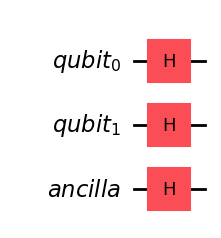

In [9]:
num_qubits = 2
K = 3   # number of iterations

qubit = QuantumRegister(num_qubits, 'qubit')
ancilla = AncillaRegister(1, 'ancilla')
quantum_register = list(qubit) + list(ancilla)

circuit_1 = QuantumCircuit(qubit, ancilla)

# first we initialize, taking A_0 = H here
circuit_1.h(qubit)
circuit_1.h(ancilla)

display(circuit_1.draw('mpl'))

Prep = circuit_1.to_gate()

Apply U_phi when k is odd. Apply U_phi_adj when k is even.

In [10]:
N = 2 ** num_qubits
# Define a function of range [0,1]
def g(x):
    return np.sin(x)**2

# Compute the diagonal entries of the phase oracle matrix.
# These will amplify states, prioritizing when g(x) is closer to 1.
# The possible states for x are 0, 1, ..., N-1.
diagonal_entries = [np.exp(1j * np.pi * g(x)) for x in range(N)]

# Create the diagonal matrix for the phase oracle
diagonal_matrix = np.diag(diagonal_entries)

# Create the phase oracle operator
phase_oracle = Operator(diagonal_matrix)
phase_oracle_adj = phase_oracle.adjoint()

# Creat the gates
phase_oracle_gate = UnitaryGate(phase_oracle.data, label='U_phi')
phase_oracle_adj_gate = UnitaryGate(phase_oracle_adj.data, label='U_phi_adj')

# Create gates that have a control, since the additional ancilla will control
# what we do to the main register
controlled_phase_oracle = phase_oracle_gate.control()
controlled_phase_oracle_adj = phase_oracle_adj_gate.control()

In [11]:
# Marker oracle: we alternate applying U_phi and U_phi_adj, to remain within the
# span of the correct basis vectors, for the algorithm to work.
# In other words, for odd iterations we apply U_phi
# For even iterations we apply U_phi_adj
# We set up these two gates, calling them odd_gate and even_gate.

def apply_U_Phi(circuit):
    qubit_list = [ancilla[0]] + list(qubit)   # control first, then targets
    circuit.x(ancilla[0])
    circuit.append(controlled_phase_oracle, qubit_list)
    circuit.x(ancilla[0])
    circuit.append(controlled_phase_oracle_adj, qubit_list)

U_phi_circuit = QuantumCircuit(qubit, ancilla, name="U_phi")
apply_U_Phi(U_phi_circuit)
Uodd = U_phi_circuit.to_gate(label='Uodd')

U_phi_adjoint_circuit = U_phi_circuit.inverse()
Ueven = U_phi_adjoint_circuit.to_gate(label='Ueven')


In [12]:
# When A_0 = H, diffuser is the same as in Grover's algorithm
diffuser_circuit = QuantumCircuit(qubit, ancilla, name="diffuser")
diffuser_circuit.append(Prep, quantum_register)
diffuser_circuit.x(quantum_register)
diffuser_circuit.mcp(np.pi, quantum_register[:-1], quantum_register[-1])  # replaces mcz
diffuser_circuit.x(quantum_register)
diffuser_circuit.append(Prep.inverse(), quantum_register)
D = diffuser_circuit.to_gate(label="Diffuser")

This is where we run the iterations on the circuit

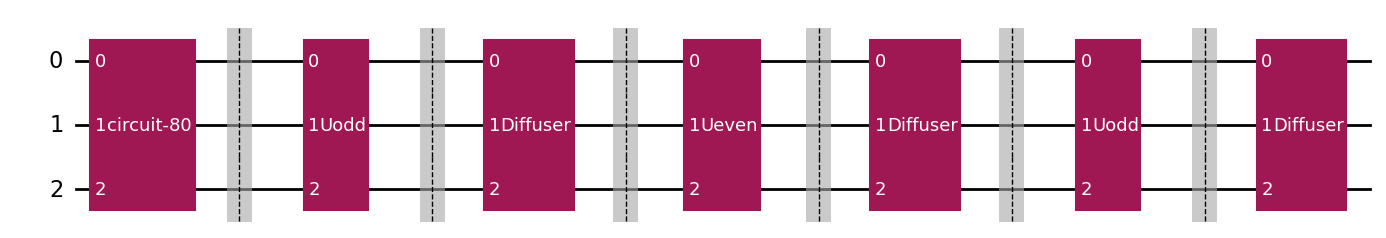

In [13]:
final_circuit = QuantumCircuit(quantum_register, name="NBQAA circuit")

final_circuit.compose(Prep, qubits=quantum_register[:], inplace=True) # Step 1: initialize

# when j=0 we are on iteration 1 which is odd, so check parity of j+1 instead
for j in range(K):                              # Step 2: for k := 1 to K
    k = j + 1
    if k % 2 == 1:                                # Step 3-4: odd -> U_phi
        final_circuit.barrier()
        final_circuit.append(Uodd, quantum_register)
        final_circuit.barrier()
    else:                                          # Step 5-6: even -> U_phi^dagger
        final_circuit.barrier()
        final_circuit.append(Ueven, quantum_register)
        final_circuit.barrier()
    final_circuit.append(D, quantum_register)       # diffuser, every iteration

final_circuit.draw(output="mpl")

In [14]:
final_state = Statevector(final_circuit)
probs = final_state.probabilities_dict()

x_probs = [0.0] * N
for bitstring, p in probs.items():
    main_bits = bitstring[1:]     # drop ancilla bit (leftmost char)
    x = int(main_bits, 2)
    x_probs[x] += p

print(f"After K={K} iterations:")
for x in range(N):
    print(f"  x={x}: p={x_probs[x]:.4f}  (phi(x)={np.pi*g(x):.4f}, cos={np.cos(np.pi*g(x)):.4f})")

After K=3 iterations:
  x=0: p=0.0427  (phi(x)=0.0000, cos=1.0000)
  x=1: p=0.4274  (phi(x)=2.2245, cos=-0.6081)
  x=2: p=0.4867  (phi(x)=2.5975, cos=-0.8556)
  x=3: p=0.0432  (phi(x)=0.0626, cos=0.9980)
